# Polymarket 天氣市場回測

**策略**：在結算前 T-N 小時，買入當時市場最看好的溫度選項（共識買入）

**資料來源**：WU 實測最高溫 作為 Polymarket 結算代理

---

## 使用方式
1. 修改下方 `⚙️ 參數設定` 的城市與策略
2. 全部執行（Run All）
3. 最底部會出現績效折線圖

## ⚙️ 參數設定（只需改這裡）

In [26]:
# ── 城市選擇 ──────────────────────────────────────────────────────────────────
# 可用城市：
#   "us/ny/new-york-city/KLGA"   NYC
#   "us/il/chicago/KORD"         Chicago
#   "gb/london/EGLC"             London
#   "us/fl/miami/KMIA"           Miami
#   "us/ga/atlanta/KATL"         Atlanta
#   "us/tx/dallas/KDAL"          Dallas
#   "us/wa/seatac/KSEA"          Seattle
#   "ca/mississauga/CYYZ"        Toronto
#   "fr/paris/LFPG"              Paris
#   "tr/çubuk/LTAC"              Ankara
#   "kr/incheon/RKSI"            Incheon
#   "nz/wellington/NZWN"         Wellington
#   "br/guarulhos/SBGR"          Sao Paulo
#   "ar/ezeiza/SAEZ"             Buenos Aires
#   "ALL"                        全部 14 城市

CITY = "gb/london/EGLC"

# ── 進場設定 ──────────────────────────────────────────────────────────────────
LEAD_HOURS = 24          # 距結算幾小時前進場（建議：6 / 12 / 24）
LEAD_TOL   = 1.5         # lead time 容忍範圍（±小時）
SETTLE_RULE = "nearest"  # 結算規則："nearest"（四捨五入）或 "floor"（無條件捨去）
MAX_PROB_FILTER = 0.8    # 過濾過度確信的場次（例如 0.80 = 不買 yes_prob > 80% 的）

# ── 下注策略 ──────────────────────────────────────────────────────────────────
STRATEGY = "fixed"       # "fixed"（固定金額）或 "fractional"（固定比例）

FIXED_BET = 5.0          # fixed：每次下注金額
FRACTION  = 0.05         # fractional：每次下注佔資金比例（2% = Kelly 保守版）

# ── 初始資金 ──────────────────────────────────────────────────────────────────
INITIAL_CAPITAL = 30.0

# ── 手續費設定（從嚴：全程 Taker，無免費期）─────────────────────────────────
# 動態費率公式：fee_rate = PEAK_FEE × 4p(1-p)，在 p=0.5 時最高（1.25%）
PEAK_FEE_RATE = 0.0125   # 天氣市場 peak taker fee = 1.25%

## 🔧 核心程式（不需修改）

In [21]:
import os, re, sys
from pathlib import Path
from collections import defaultdict

import psycopg2
import psycopg2.extras
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

# ── 中文字型（macOS）────────────────────────────────────────────────────────
plt.rcParams["font.family"] = ["Arial Unicode MS", "Heiti TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

load_dotenv(Path("..") / ".env")

ALL_CITIES = [
    "us/ny/new-york-city/KLGA", "us/il/chicago/KORD", "gb/london/EGLC",
    "us/fl/miami/KMIA", "us/ga/atlanta/KATL", "us/tx/dallas/KDAL",
    "us/wa/seatac/KSEA", "ca/mississauga/CYYZ", "fr/paris/LFPG",
    "tr/çubuk/LTAC", "kr/incheon/RKSI", "nz/wellington/NZWN",
    "br/guarulhos/SBGR", "ar/ezeiza/SAEZ",
]

CITY_NAMES = {
    "us/ny/new-york-city/KLGA": "NYC",
    "us/il/chicago/KORD":       "Chicago",
    "gb/london/EGLC":           "London",
    "us/fl/miami/KMIA":         "Miami",
    "us/ga/atlanta/KATL":       "Atlanta",
    "us/tx/dallas/KDAL":        "Dallas",
    "us/wa/seatac/KSEA":        "Seattle",
    "ca/mississauga/CYYZ":      "Toronto",
    "fr/paris/LFPG":            "Paris",
    "tr/çubuk/LTAC":            "Ankara",
    "kr/incheon/RKSI":          "Incheon",
    "nz/wellington/NZWN":       "Wellington",
    "br/guarulhos/SBGR":        "São Paulo",
    "ar/ezeiza/SAEZ":           "Buenos Aires",
}

_RANGE_RE = re.compile(r"(-?\d+)\s*-\s*(-?\d+)")
_BOUND_RE = re.compile(r"(-?\d+)\s*°?[CF]?\s*(or higher|or above|or below)", re.I)

def covers(label: str, actual: float, rule: str = "nearest") -> bool:
    m = _BOUND_RE.search(label)
    if m:
        t = int(m.group(1)); tail = m.group(2).lower()
        return actual >= t if ("high" in tail or "above" in tail) else actual < t + 1
    m = _RANGE_RE.search(label)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return lo <= actual < hi + 1
    m = re.search(r"(-?\d+)", label)
    if m:
        t = int(m.group(1))
        return abs(actual - t) < 0.5 if rule == "nearest" else t <= actual < t + 1
    return False

def f_to_c(f: float) -> float:
    return (f - 32) * 5 / 9

print("✅ 套件載入完成")


✅ 套件載入完成


In [27]:
import datetime

def taker_fee(prob: float, peak: float) -> float:
    """Polymarket 動態 Taker 費率：peak × 4p(1-p)，在 p=0.5 最高"""
    return peak * 4 * prob * (1 - prob)


def load_city_data(conn, loc: str, lead_hours: float, tol: float) -> list[dict]:
    lo, hi = lead_hours - tol, lead_hours + tol
    sql = """
    WITH snaps AS (
      SELECT DISTINCT ON (market_date)
             market_date, snapshot_time, hours_before_close
      FROM market_snapshots
      WHERE location_key = %s AND hours_before_close BETWEEN %s AND %s
      ORDER BY market_date, ABS(hours_before_close - %s) ASC
    )
    SELECT s.market_date, ms.option_label, ms.yes_prob,
           wds.official_high_f, c.celsius
    FROM snaps s
    JOIN market_snapshots ms
      ON ms.location_key = %s AND ms.market_date = s.market_date
     AND ms.snapshot_time = s.snapshot_time
    JOIN weather_daily_summary wds
      ON wds.location_key = %s AND wds.obs_date = s.market_date
    JOIN cities c ON c.location_key = %s
    WHERE wds.official_high_f IS NOT NULL AND ms.yes_prob IS NOT NULL
    ORDER BY s.market_date, ms.yes_prob DESC
    """
    with conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor) as cur:
        cur.execute(sql, (loc, lo, hi, lead_hours, loc, loc, loc))
        rows = cur.fetchall()

    days = defaultdict(list)
    for r in rows:
        days[r["market_date"]].append({
            "label":   r["option_label"],
            "p":       float(r["yes_prob"]),
            "high_f":  float(r["official_high_f"]),
            "celsius": r["celsius"],
        })
    return [{"date": d, "opts": v} for d, v in sorted(days.items())]


def run_backtest(data: list[dict], strategy: str, initial: float,
                 fixed_bet: float, fraction: float,
                 settle_rule: str, max_prob: float,
                 peak_fee: float) -> pd.DataFrame:
    capital = initial
    records = []

    for day in data:
        opts = sorted(day["opts"], key=lambda o: -o["p"])
        top  = opts[0]
        if top["p"] > max_prob:
            continue

        actual = f_to_c(top["high_f"]) if top["celsius"] else top["high_f"]
        won    = covers(top["label"], actual, settle_rule)

        bet      = fixed_bet if strategy == "fixed" else capital * fraction
        fee_rate = taker_fee(top["p"], peak_fee)
        fee_amt  = bet * fee_rate

        gross_pnl = bet * (1 / top["p"] - 1) if won else -bet
        net_pnl   = gross_pnl - fee_amt
        capital  += net_pnl

        records.append({
            "date":      day["date"],
            "label":     top["label"],
            "prob":      top["p"],
            "actual":    actual,
            "won":       won,
            "bet":       bet,
            "fee_rate":  fee_rate,
            "fee_amt":   fee_amt,
            "gross_pnl": gross_pnl,
            "net_pnl":   net_pnl,
            "capital":   capital,
        })

    return pd.DataFrame(records)


conn = psycopg2.connect(os.environ["DATABASE_URL"], sslmode="require")
print("✅ DB 連線成功")


✅ DB 連線成功


In [28]:
cities  = ALL_CITIES if CITY == "ALL" else [CITY]
results = {}

for loc in cities:
    data = load_city_data(conn, loc, LEAD_HOURS, LEAD_TOL)
    if not data:
        print(f"  ⚠️  {CITY_NAMES.get(loc, loc)}：無資料")
        continue
    df = run_backtest(data, STRATEGY, INITIAL_CAPITAL,
                      FIXED_BET, FRACTION, SETTLE_RULE, MAX_PROB_FILTER,
                      PEAK_FEE_RATE)
    results[loc] = df

    name      = CITY_NAMES.get(loc, loc)
    wins      = df["won"].sum()
    total     = len(df)
    final     = df["capital"].iloc[-1]
    total_fee = df["fee_amt"].sum()
    gross_roi = df["gross_pnl"].sum() / df["bet"].sum() * 100
    net_roi   = df["net_pnl"].sum()   / df["bet"].sum() * 100

    print(f"  {name:<14} {total}天  {wins}勝/{total-wins}敗  "
          f"勝率={wins/total:.1%}  毛ROI={gross_roi:+.1f}%  "
          f"手續費=-${total_fee:.2f}  淨ROI={net_roi:+.1f}%  最終=${final:.2f}")


  London         56天  33勝/23敗  勝率=58.9%  毛ROI=+24.5%  手續費=-$3.38  淨ROI=+23.3%  最終=$95.12


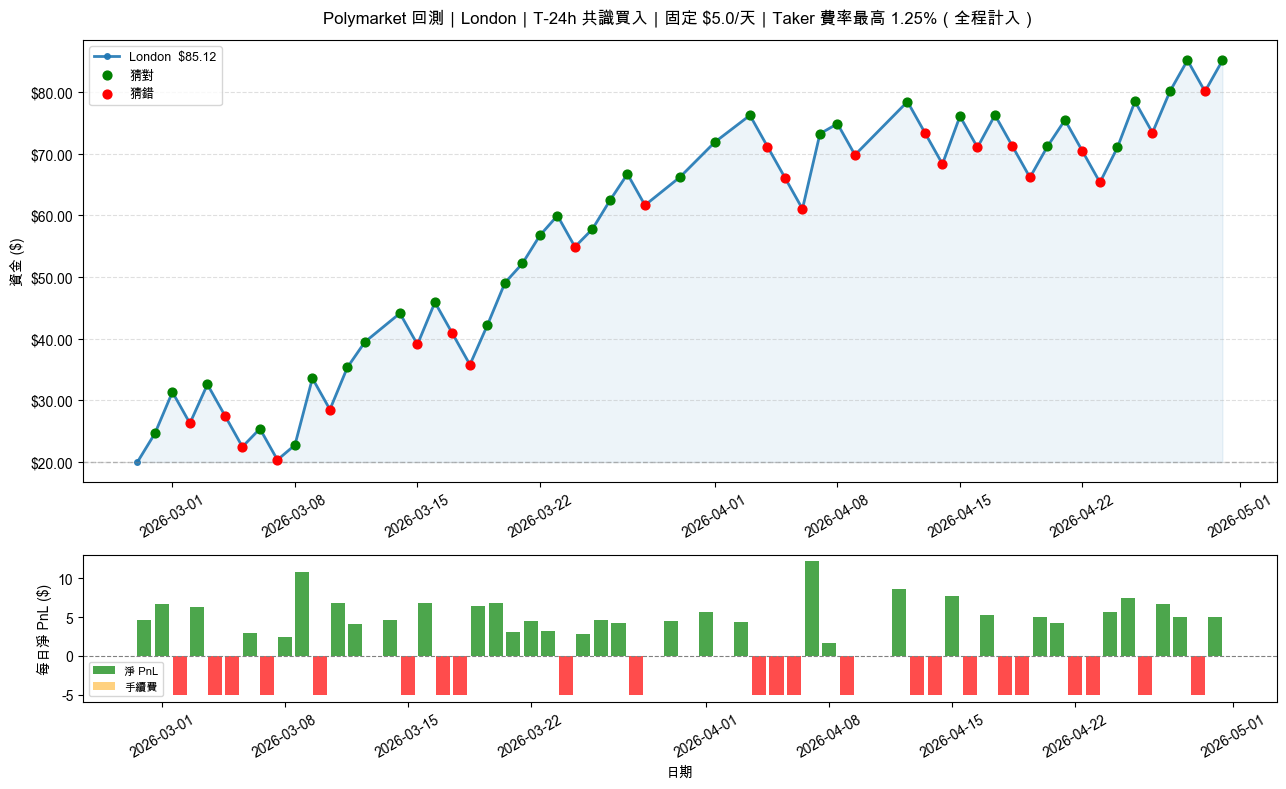

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                         gridspec_kw={"height_ratios": [3, 1]})
ax1, ax2 = axes
colors   = plt.cm.tab10.colors
is_multi = len(results) > 1

for i, (loc, df) in enumerate(results.items()):
    name  = CITY_NAMES.get(loc, loc)
    color = colors[i % len(colors)]
    dates = pd.to_datetime(df["date"])
    final = df["capital"].iloc[-1]

    dates_plot   = pd.concat([pd.Series([dates.iloc[0] - pd.Timedelta(days=1)]), dates])
    capital_plot = pd.concat([pd.Series([INITIAL_CAPITAL]), df["capital"]])

    ax1.plot(dates_plot, capital_plot, color=color, linewidth=2,
             label=f"{name}  ${final:.2f}",
             marker="o" if not is_multi else None, markersize=4, alpha=0.9)

    if not is_multi:
        wins_df = df[df["won"]];  loss_df = df[~df["won"]]
        ax1.scatter(pd.to_datetime(wins_df["date"]), wins_df["capital"],
                    color="green", zorder=5, s=40, label="猜對")
        ax1.scatter(pd.to_datetime(loss_df["date"]), loss_df["capital"],
                    color="red",   zorder=5, s=40, label="猜錯")

        bar_colors = df["net_pnl"].apply(lambda x: "green" if x > 0 else "red")
        ax2.bar(pd.to_datetime(df["date"]), df["net_pnl"],
                color=bar_colors, alpha=0.7, width=0.8, label="淨 PnL")
        ax2.bar(pd.to_datetime(df["date"]), -df["fee_amt"],
                color="orange", alpha=0.5, width=0.8, label="手續費")
        ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
        ax2.set_ylabel("每日淨 PnL ($)", fontsize=10)
        ax2.set_xlabel("日期", fontsize=10)
        ax2.tick_params(axis="x", rotation=30)
        ax2.legend(fontsize=8, loc="lower left")

ax1.axhline(INITIAL_CAPITAL, color="gray", linewidth=1, linestyle="--", alpha=0.5)
if not is_multi:
    ax1.fill_between(dates_plot, INITIAL_CAPITAL, capital_plot,
                     alpha=0.08, color=colors[0])

strategy_label = (f"固定 ${FIXED_BET}/天" if STRATEGY == "fixed"
                  else f"固定比例 {FRACTION*100:.0f}%")
city_label = CITY_NAMES.get(CITY, CITY) if CITY != "ALL" else "全部城市"
ax1.set_title(
    f"Polymarket 回測｜{city_label}｜T-{LEAD_HOURS}h 共識買入｜{strategy_label}"
    f"｜Taker 費率最高 {PEAK_FEE_RATE*100:.2f}%（全程計入）",
    fontsize=12, fontweight="bold", pad=12
)
ax1.set_ylabel("資金 ($)", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.2f"))
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.tick_params(axis="x", rotation=30)

if is_multi:
    ax2.set_visible(False)
    ax1.set_xlabel("日期", fontsize=10)

plt.tight_layout()
# plt.savefig("output/backtest_result.png", dpi=150, bbox_inches="tight")
plt.show()
# print("✅ 圖表已顯示")


## 🎲 Bootstrap Monte Carlo 模擬

對實際交易記錄做有放回重採樣，估計策略績效的不確定性範圍。

城市               交易     盈利機率      5th      中位數     95th       實際     實際分位
--------------------------------------------------------------------------
  London         56    94.0%  $ 17.56  $ 89.18  $ 153.42  $ 85.12    46.3%


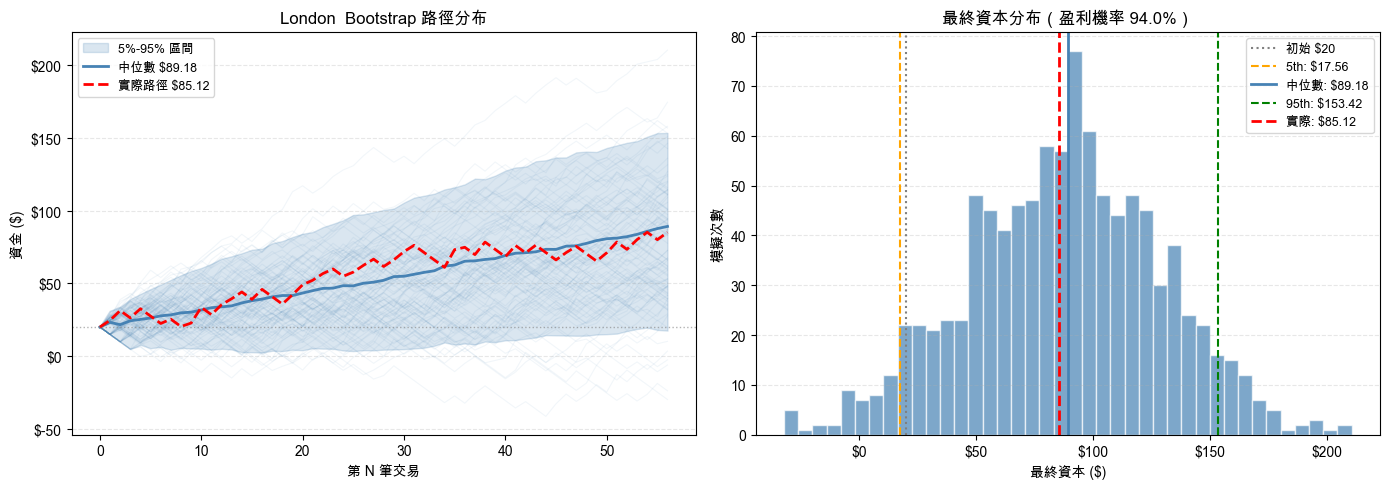

In [25]:
import numpy as np

N_SIMULATIONS = 1_000
rng = np.random.default_rng(42)

# ── 對每個城市跑 Bootstrap MC ────────────────────────────────────────────────
mc_summary = []
mc_finals  = {}   # loc -> final_capitals array（給圖表用）
mc_paths   = {}   # loc -> paths array（給單城市路徑圖用）

for loc, df_mc in results.items():
    pnls     = df_mc["net_pnl"].values
    n_trades = len(pnls)
    if n_trades == 0:
        continue

    paths = np.zeros((N_SIMULATIONS, n_trades + 1))
    paths[:, 0] = INITIAL_CAPITAL
    for i in range(N_SIMULATIONS):
        sampled = rng.choice(pnls, size=n_trades, replace=True)
        paths[i, 1:] = INITIAL_CAPITAL + np.cumsum(sampled)

    final_capitals = paths[:, -1]
    p5, p50, p95   = np.percentile(final_capitals, [5, 50, 95])
    win_prob       = (final_capitals > INITIAL_CAPITAL).mean()
    actual_final   = df_mc["capital"].iloc[-1]

    mc_finals[loc] = final_capitals
    mc_paths[loc]  = paths
    mc_summary.append({
        "城市":     CITY_NAMES.get(loc, loc),
        "交易數":   n_trades,
        "盈利機率": win_prob,
        "5th":      p5,
        "中位數":   p50,
        "95th":     p95,
        "實際":     actual_final,
        "實際分位": (final_capitals < actual_final).mean(),  # 實際落在幾 percentile
    })

summary_df = pd.DataFrame(mc_summary).sort_values("盈利機率", ascending=False)

# ── 輸出比較表 ───────────────────────────────────────────────────────────────
print(f"{'城市':<14} {'交易':>4} {'盈利機率':>8} {'5th':>8} {'中位數':>8} {'95th':>8} {'實際':>8} {'實際分位':>8}")
print("-" * 74)
for _, r in summary_df.iterrows():
    print(f"  {r['城市']:<12} {int(r['交易數']):>4}  "
          f"{r['盈利機率']:>7.1%}  "
          f"${r['5th']:>6.2f}  ${r['中位數']:>6.2f}  ${r['95th']:>7.2f}  "
          f"${r['實際']:>6.2f}  {r['實際分位']:>7.1%}")

# ── 圖表 ────────────────────────────────────────────────────────────────────
n_cities = len(mc_finals)
is_multi = n_cities > 1

if is_multi:
    # ALL 模式：各城市並排分布箱型圖 + 勝率排名
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 左：box plot（各城市最終資本分布）
    city_names_ordered = [CITY_NAMES.get(loc, loc) for loc in mc_finals]
    data_ordered = [mc_finals[loc] for loc in mc_finals]
    # 按盈利機率排序
    order = summary_df["城市"].tolist()
    city_data_sorted = [(name, mc_finals[loc])
                        for name in order
                        for loc in mc_finals
                        if CITY_NAMES.get(loc, loc) == name]
    names_sorted = [x[0] for x in city_data_sorted]
    data_sorted  = [x[1] for x in city_data_sorted]

    bp = ax1.boxplot(data_sorted, vert=True, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2),
                     whiskerprops=dict(linewidth=1.2),
                     flierprops=dict(marker=".", markersize=3, alpha=0.3))
    colors_box = plt.cm.RdYlGn(
        [(summary_df[summary_df["城市"]==n]["盈利機率"].values[0]) for n in names_sorted]
    )
    for patch, color in zip(bp["boxes"], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax1.axhline(INITIAL_CAPITAL, color="gray", linewidth=1.2,
                linestyle="--", alpha=0.7, label=f"初始資本 ${INITIAL_CAPITAL:.0f}")
    ax1.set_xticks(range(1, len(names_sorted) + 1))
    ax1.set_xticklabels(names_sorted, rotation=35, ha="right", fontsize=9)
    ax1.set_ylabel("最終資本 ($)", fontsize=10)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
    ax1.set_title("各城市最終資本分布（按盈利機率排序）", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.grid(axis="y", linestyle="--", alpha=0.3)

    # 右：盈利機率橫條圖
    win_probs = [summary_df[summary_df["城市"]==n]["盈利機率"].values[0] for n in names_sorted]
    bar_colors = ["#2ecc71" if p >= 0.7 else "#f39c12" if p >= 0.5 else "#e74c3c"
                  for p in win_probs]
    bars = ax2.barh(names_sorted, [p * 100 for p in win_probs],
                    color=bar_colors, alpha=0.85, edgecolor="white")
    ax2.axvline(50, color="gray", linewidth=1.2, linestyle="--", alpha=0.7)
    for bar, p in zip(bars, win_probs):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{p:.1%}", va="center", fontsize=9)
    ax2.set_xlabel("盈利機率 (%)", fontsize=10)
    ax2.set_xlim(0, 105)
    ax2.set_title("Bootstrap 盈利機率排名", fontsize=12, fontweight="bold")
    ax2.grid(axis="x", linestyle="--", alpha=0.3)

else:
    # 單城市：路徑圖 + 分布直方圖
    loc = list(mc_finals.keys())[0]
    paths        = mc_paths[loc]
    final_caps   = mc_finals[loc]
    name_mc      = CITY_NAMES.get(loc, loc)
    df_mc        = results[loc]
    p5, p50, p95 = np.percentile(final_caps, [5, 50, 95])
    win_prob     = (final_caps > INITIAL_CAPITAL).mean()
    n_trades     = len(df_mc)
    x = np.arange(n_trades + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(x, paths[::10].T, color="steelblue", alpha=0.07, linewidth=0.8)
    ax1.fill_between(x,
        np.percentile(paths, 5,  axis=0),
        np.percentile(paths, 95, axis=0),
        alpha=0.2, color="steelblue", label="5%-95% 區間")
    ax1.plot(x, np.percentile(paths, 50, axis=0),
             color="steelblue", linewidth=2, label=f"中位數 ${p50:.2f}")
    ax1.plot(x, [INITIAL_CAPITAL] + list(df_mc["capital"]),
             color="red", linewidth=2, linestyle="--",
             label=f"實際路徑 ${df_mc['capital'].iloc[-1]:.2f}")
    ax1.axhline(INITIAL_CAPITAL, color="gray", linewidth=1, linestyle=":", alpha=0.6)
    ax1.set_title(f"{name_mc}  Bootstrap 路徑分布", fontsize=12, fontweight="bold")
    ax1.set_xlabel("第 N 筆交易", fontsize=10)
    ax1.set_ylabel("資金 ($)", fontsize=10)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
    ax1.legend(fontsize=9)
    ax1.grid(axis="y", linestyle="--", alpha=0.3)

    ax2.hist(final_caps, bins=40, color="steelblue", alpha=0.7, edgecolor="white")
    ax2.axvline(INITIAL_CAPITAL, color="gray",  linewidth=1.5, linestyle=":", label=f"初始 ${INITIAL_CAPITAL:.0f}")
    ax2.axvline(p5,  color="orange",    linewidth=1.5, linestyle="--", label=f"5th: ${p5:.2f}")
    ax2.axvline(p50, color="steelblue", linewidth=2,   label=f"中位數: ${p50:.2f}")
    ax2.axvline(p95, color="green",     linewidth=1.5, linestyle="--", label=f"95th: ${p95:.2f}")
    ax2.axvline(df_mc["capital"].iloc[-1], color="red", linewidth=2, linestyle="--",
                label=f"實際: ${df_mc['capital'].iloc[-1]:.2f}")
    ax2.set_title(f"最終資本分布（盈利機率 {win_prob:.1%}）", fontsize=12, fontweight="bold")
    ax2.set_xlabel("最終資本 ($)", fontsize=10)
    ax2.set_ylabel("模擬次數", fontsize=10)
    ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
    ax2.legend(fontsize=9)
    ax2.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
